# Telco Customer Churn Analysis
Why customers leave, who is most likely to leave, and how to keep them.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.shape

(7043, 21)

## 1. Clean the data

In [2]:
# TotalCharges has blank strings for new customers (tenure = 0), fix that
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# make Churn easy to use in math
df['ChurnFlag'] = (df['Churn'] == 'Yes').astype(int)

print("Rows:", len(df))
df.head()

Rows: 7043


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## 2. Overall churn rate

Total customers: 7,043
Churned: 1,869
Churn rate: 26.5%


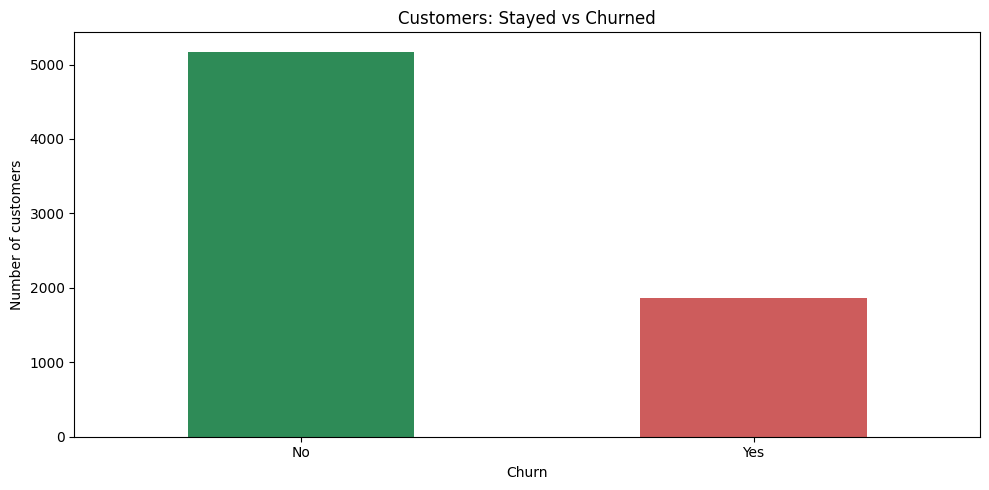

In [3]:
total_customers = len(df)
churned = df['ChurnFlag'].sum()
churn_rate = churned / total_customers

print(f"Total customers: {total_customers:,}")
print(f"Churned: {churned:,}")
print(f"Churn rate: {churn_rate:.1%}")

df['Churn'].value_counts().plot(kind='bar', color=['seagreen','indianred'])
plt.title("Customers: Stayed vs Churned")
plt.ylabel("Number of customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. How long do customers stay?
tenure = number of months as a customer.

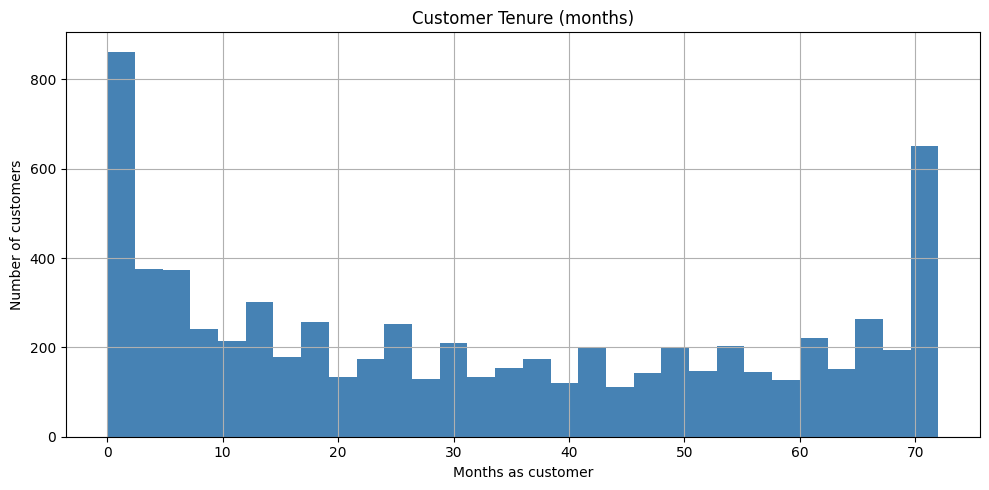

Churn
No     37.6
Yes    18.0
Name: tenure, dtype: float64


In [4]:
df['tenure'].hist(bins=30, color='steelblue')
plt.title("Customer Tenure (months)")
plt.xlabel("Months as customer")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

print(df.groupby('Churn')['tenure'].mean().round(1))

## 4. Tenure cohorts
Group customers into tenure buckets and check churn rate per group. No signup date column here, so tenure buckets act as our cohorts.

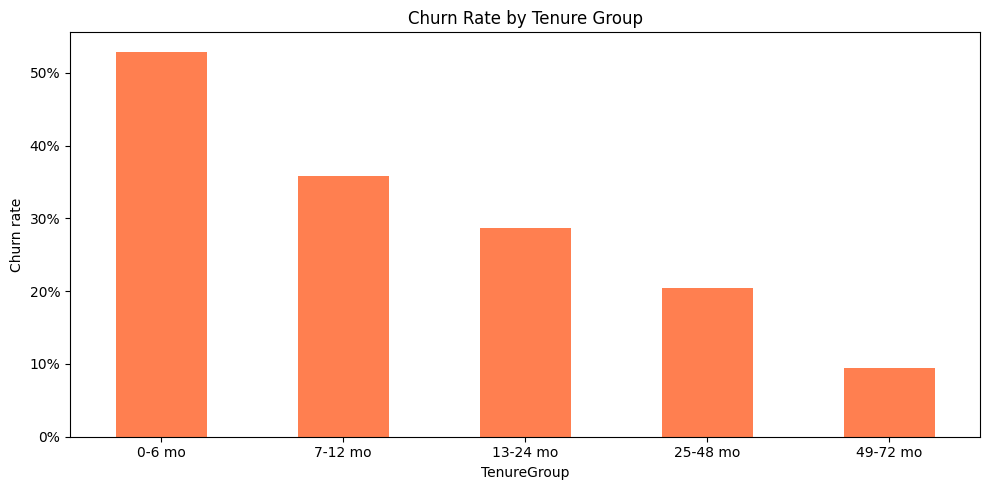

TenureGroup
0-6 mo      0.529372
7-12 mo     0.358865
13-24 mo    0.287109
25-48 mo    0.203890
49-72 mo    0.095132
Name: ChurnFlag, dtype: float64

In [5]:
bins = [0, 6, 12, 24, 48, 72]
labels = ['0-6 mo', '7-12 mo', '13-24 mo', '25-48 mo', '49-72 mo']
df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

cohort_churn = df.groupby('TenureGroup')['ChurnFlag'].mean()

ax = cohort_churn.plot(kind='bar', color='coral')
ax.set_title("Churn Rate by Tenure Group")
ax.set_ylabel("Churn rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

cohort_churn

## 5. Churn by contract type
Contract length is usually the biggest churn driver.

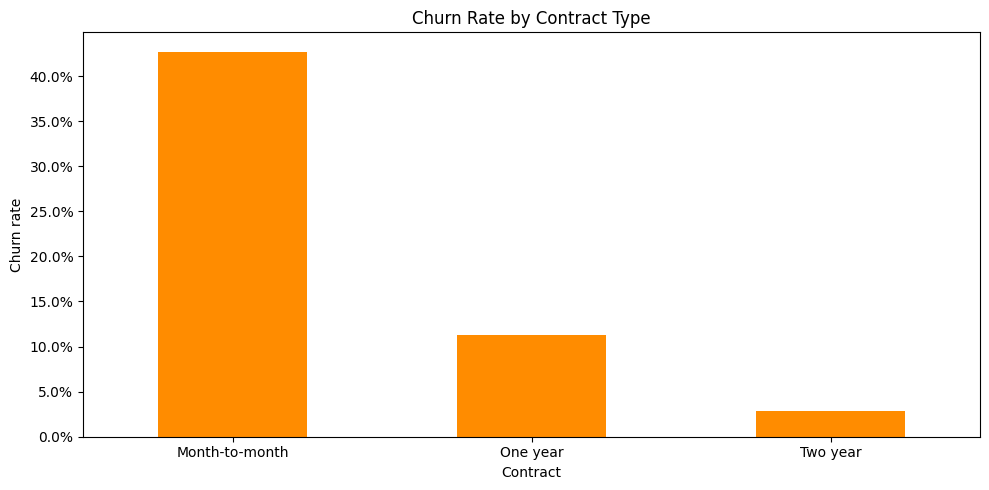

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: ChurnFlag, dtype: float64

In [6]:
contract_churn = df.groupby('Contract')['ChurnFlag'].mean().sort_values(ascending=False)

ax = contract_churn.plot(kind='bar', color='darkorange')
ax.set_title("Churn Rate by Contract Type")
ax.set_ylabel("Churn rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

contract_churn

## 6. Churn by internet service and add-ons
Check if missing security/support add-ons pushes people to leave.

InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: ChurnFlag, dtype: float64


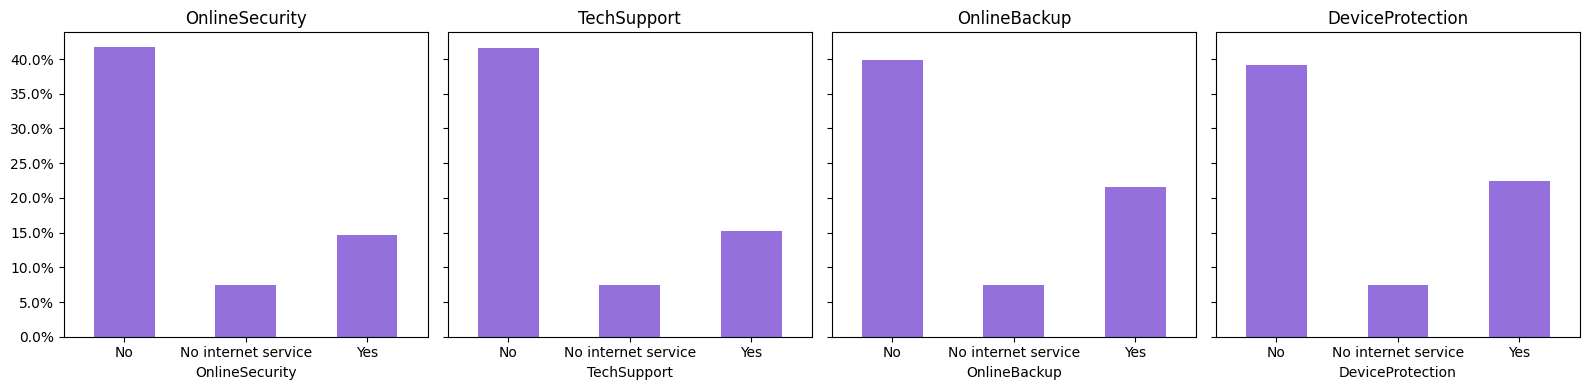

In [7]:
internet_churn = df.groupby('InternetService')['ChurnFlag'].mean().sort_values(ascending=False)
print(internet_churn)

addons = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection']
fig, axes = plt.subplots(1, len(addons), figsize=(16,4), sharey=True)
for ax, col in zip(axes, addons):
    df.groupby(col)['ChurnFlag'].mean().plot(kind='bar', ax=ax, color='mediumpurple')
    ax.set_title(col)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 7. Churn by payment method and charges

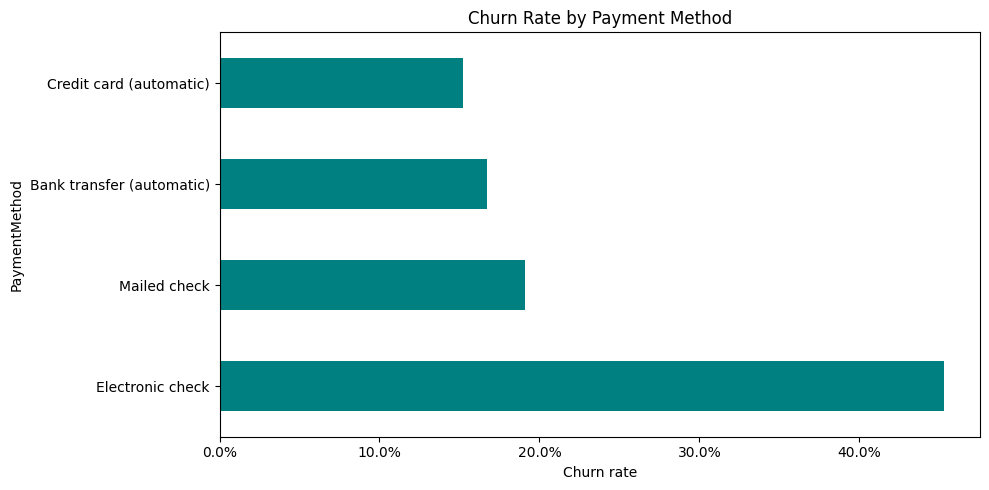

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


In [8]:
payment_churn = df.groupby('PaymentMethod')['ChurnFlag'].mean().sort_values(ascending=False)

ax = payment_churn.plot(kind='barh', color='teal')
ax.set_title("Churn Rate by Payment Method")
ax.set_xlabel("Churn rate")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

## 8. Customer lifetime value snapshot

In [9]:
avg_monthly = df['MonthlyCharges'].mean()
avg_tenure_active = df[df['Churn']=='No']['tenure'].mean()
avg_tenure_churned = df[df['Churn']=='Yes']['tenure'].mean()

print(f"Avg monthly charge: £{avg_monthly:.2f}")
print(f"Avg tenure (active customers): {avg_tenure_active:.1f} months")
print(f"Avg tenure (churned customers): {avg_tenure_churned:.1f} months")
print(f"Rough revenue lost per churned customer so far: £{(avg_monthly*avg_tenure_churned):.2f}")

Avg monthly charge: £64.76
Avg tenure (active customers): 37.6 months
Avg tenure (churned customers): 18.0 months
Rough revenue lost per churned customer so far: £1164.36


## 9. Insights & recommendations

**What we found:**
- Overall churn rate is **~27%** — about 1 in 4 customers leave.
- Customers with **month-to-month contracts** churn far more than one-year or two-year contracts. Contract length is the single biggest churn driver.
- **New customers churn the most.** Churn is highest in the first 6 months, then drops sharply the longer someone stays.
- Customers without **online security or tech support** churn more. These add-ons seem to build stickiness.
- **Fiber optic** internet customers churn more than DSL customers, possibly due to price or service issues.
- Customers paying by **electronic check** churn more than those on auto-pay methods (bank transfer, credit card).
- Churned customers have **higher average monthly charges**, meaning price sensitivity plays a role.

**What the business should do:**
1. **Push customers toward longer contracts.** Offer a discount or perk for switching from month-to-month to a 1-year plan, especially in the first 6 months when churn risk is highest.
2. **Target the first 6 months with an onboarding/retention program.** Check-ins, tutorials, or early loyalty perks can reduce early churn.
3. **Bundle in security and tech support** for free or cheap in the first few months, since customers with these add-ons stick around longer.
4. **Investigate fiber optic service quality or pricing**, since churn is highest there.
5. **Encourage auto-pay** (bank transfer/credit card) over electronic check, since manual payment correlates with higher churn — friction at billing time may be a factor.
6. **Watch high monthly-charge customers closely** — they're the most price-sensitive and most likely to leave if they don't see enough value.
